# Full versus window-restricted entropy
Matched analysis of all 100 saved 20 by 32 hard-wall pure endpoints at cycle 64; average all 32 origins within each trajectory, then trajectories. Compare full entropy with the contribution from eigenvalues inside a centered spectral window.

In [1]:
import os
if 'AVAILABLE_CPUS' not in globals():AVAILABLE_CPUS=sorted(os.sched_getaffinity(0))
CPU_RANGE=(8,9)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1));assert set(selected).issubset(AVAILABLE_CPUS)
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
from threadpoolctl import threadpool_limits
limits=threadpool_limits(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9]


## Estimator and interpretation
For occupation eigenvalue $\nu=(1+\lambda)/2$, the entropy contribution is $h(\nu)=-\nu\ln\nu-(1-\nu)\ln(1-\nu)$. Compare
$$S_L(A_y)=\sum_{|\lambda_j|\le L}h((1+\lambda_j)/2)$$
with the full von Neumann entropy $S_1$. Origins are averaged inside each trajectory before the ensemble average. There is no renormalization after dropping modes. The original raw spectra are unchanged; numerical excursions within $10^{-8}$ are clipped only when evaluating entropy.

Fits use $a+b\ln[(N_y/\pi)\sin(\pi A_y/N_y)]$, $N_y=32$ and widths 5–16. These are the same unanchored two-parameter, fixed-size fits used for the preceding mode-count comparison, **not** the technical report's joint multi-size anchored fit. Coefficient uncertainties propagate correlations across widths by fitting each trajectory-level origin average and computing the SEM. R-squared describes the mean curve and does not establish universal scaling.

Removing modes changes the observable; a cutoff-dependent coefficient is not automatically the central-charge coefficient of the full entropy. In particular, $h(\nu)$ already vanishes at the pure endpoints, while the counting weight is one per included mode. Sources: [Peschel–Eisler](https://arxiv.org/abs/0906.1663) for free-fermion entropy; [Calabrese–Cardy](https://arxiv.org/abs/hep-th/0405152) for interval entropy scaling.

## Analysis and metadata
The helper checks the spectrum-cache hash and records its production provenance. It cross-checks the full half-system entropy against the earlier independent entropy analysis.

In [2]:
from pathlib import Path
import sys,json,subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display,Image
OUT=Path.cwd();sys.path.insert(0,str(OUT))
from analyze_entropy_windows import analyze
fits,diagnostics=analyze()
print(json.dumps({k:v for k,v in diagnostics.items() if k not in ('input_provenance','fits')},indent=2))
display(fits)
data=dict(np.load(OUT/'entropy_window_statistics.npz'))

Entropy contributions by spectral window:   0%|          | 0/16 [00:00<?, ?width/s]

{
  "Nx": 20,
  "Ny": 32,
  "samples": 100,
  "origins": 32,
  "cycles": 64,
  "windows": [
    0.5,
    0.9,
    0.95,
    0.99,
    0.999,
    0.9999,
    0.99999,
    1.0
  ],
  "fit_widths": [
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16
  ],
  "estimator": "sum binary entropy for abs(centered eigenvalue)<=L; average origins within trajectories, then trajectories; no renormalization",
  "fit": "unanchored ordinary least squares: a + b log[(Ny/pi)sin(pi Ay/Ny)]",
  "uncertainty": "SEM of 100 trajectory-level origin averages; full cross-width correlations propagated",
  "comparison_scope": "same fixed-size two-parameter fits as mode-count analysis, not the report joint multi-size anchored fit",
  "input_cache": "/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2/subsystem_spectr

,L,intercept,slope,slope_sem,R_squared,residual_rms,half_entropy,half_entropy_sem,half_entropy_retained_fraction
0,0.50000,3.836165,0.149277,0.006641,0.991854,0.003227,4.180853,0.008191,0.448349
1,0.90000,7.209741,0.299325,0.002303,0.999596,0.001435,7.902020,0.008554,0.847402
2,0.95000,7.775416,0.324238,0.002069,0.999699,0.001342,8.526081,0.009227,0.914325
3,0.99000,8.320397,0.352125,0.002018,0.999904,0.000822,9.136761,0.009564,0.979814
4,0.99900,8.464591,0.359919,0.002006,0.999872,0.000972,9.299117,0.009608,0.997225
5,0.99990,8.485359,0.360938,0.001997,0.999873,0.000972,9.322265,0.009591,0.999707
6,0.99999,8.487403,0.361092,0.001997,0.999872,0.000976,9.324663,0.009593,0.999964
7,1.00000,8.487682,0.361117,0.001997,0.999871,0.000978,9.324999,0.009593,1.000000


## Residuals of the matched fits
The full and truncated entropies each get their own intercept and slope. Residuals are shown over the fitted widths. Connected points guide the eye; widths and windows are correlated.

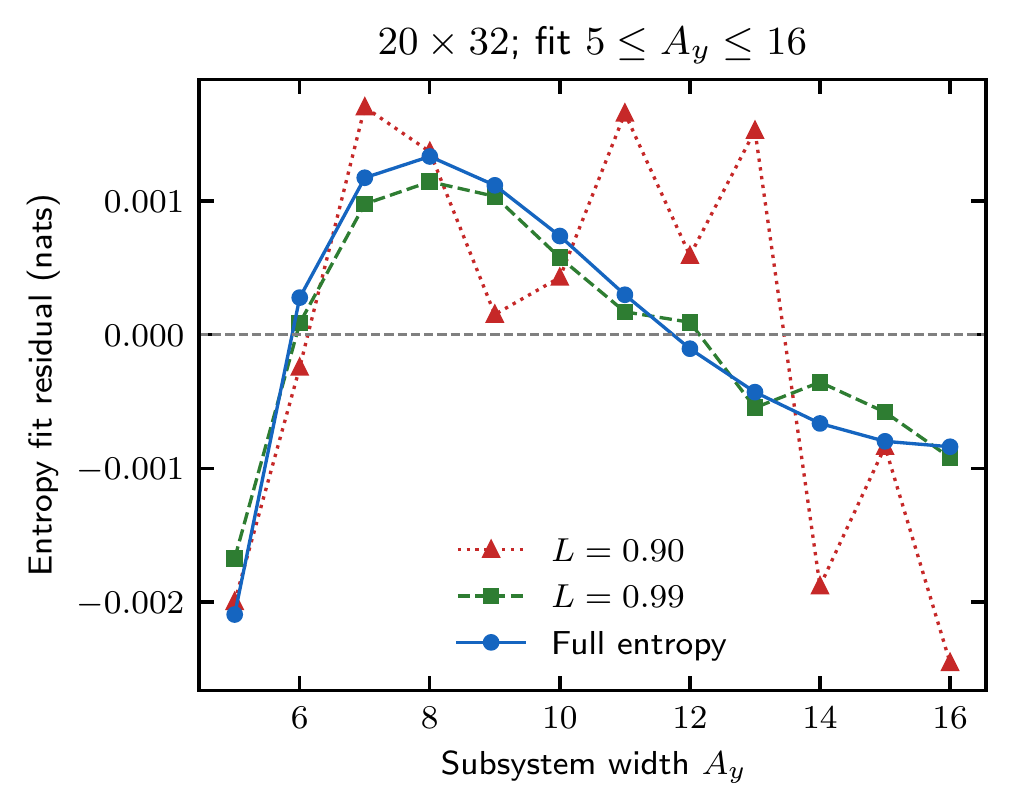

In [3]:
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,'text.usetex':True,
                     'xtick.direction':'in','ytick.direction':'in'})
fig,ax=plt.subplots(figsize=(3.375,2.7))
for L,color,marker,style in [(.9,'#c62828','^',':'),(.99,'#2e7d32','s','--'),(1.,'#1565c0','o','-')]:
    k=int(np.flatnonzero(np.isclose(data['windows'],L,rtol=0,atol=1e-14))[0])
    ax.plot(data['widths'][data['widths']>=5],data['residuals'][k],color=color,marker=marker,ls=style,ms=3,lw=.8,
            label='Full entropy' if L==1 else r'$L=%.2f$'%L)
ax.axhline(0,color='gray',ls='--',lw=.6)
ax.set(xlabel=r'Subsystem width $A_y$',ylabel='Entropy fit residual (nats)',title=r'$20\times32$; fit $5\leq A_y\leq16$')
ax.legend(frameon=False,fontsize=8);ax.tick_params(top=True,right=True);fig.tight_layout(pad=.8)
fig.savefig(OUT/'entropy_fit_residuals.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'entropy_fit_residuals.pdf'),str(OUT/'entropy_fit_residuals')],check=True)
display(Image(filename=str(OUT/'entropy_fit_residuals.png'),width=550))

Caption: 100 independent trajectories, pure initialization with exterior product preparation, Nx=20, Ny=32, hard construction, alpha1=1, alpha2=30, nshell=1, cycle 64. Sum entropy contributions inside each spectral window before averaging 32 origins within a trajectory, then trajectories. Fits use widths 5–16. Coefficient errors in the table are trajectory SEMs retaining cross-width covariance; the residual plot shows deviations of the ensemble means, not independent samples.

## Diagnostics and result

In [4]:
full=fits.iloc[-1];central=fits[np.isclose(fits.L,.99)].iloc[0]
summary=dict(full_entropy_slope=full.slope,window_099_slope=central.slope,
 full_entropy_R_squared=full.R_squared,window_099_R_squared=central.R_squared,
 relative_slope_change=central.slope/full.slope-1,
 half_entropy_removed_fraction=1-central.half_entropy_retained_fraction,
 full_entropy_prior_difference=diagnostics['full_entropy_previous_result_difference'])
print(json.dumps(summary,indent=2))
(OUT/'comparison_summary.json').write_text(json.dumps(summary,indent=2)+'\n')
(OUT/'README.md').write_text('# Full versus window-restricted entropy\n\nMatched fixed Ny=32, widths 5–16, 100 trajectories, 32 origins. No renormalization after filtering modes.\n\n'+fits.to_string(index=False)+'\n\nA small improvement in the L=0.99 residual is accompanied by a change in slope. This is not a reproduction or revision of the technical report joint multi-size anchored central-charge fit.\n')
print('Completed: entropy table, sample statistics, input provenance, diagnostics, PDF/PNG residual figure.')

{
  "full_entropy_slope": 0.3611174743824983,
  "window_099_slope": 0.35212502808296825,
  "full_entropy_R_squared": 0.9998712304683622,
  "window_099_R_squared": 0.9999041597402246,
  "relative_slope_change": -0.024901720180965814,
  "half_entropy_removed_fraction": 0.02018633854711982,
  "full_entropy_prior_difference": 3.126388037344441e-13
}
Completed: entropy table, sample statistics, input provenance, diagnostics, PDF/PNG residual figure.
